<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v1/blob/master/Final_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 13 — Final Results

**⚠️ READ BEFORE RUNNING**

This notebook evaluates all key models on the **held-out test set** (1,500 samples, never seen during training or model selection).  
Run this **once** at the end of the project — do not use test accuracy for any further decisions.

### Models evaluated
| # | Model | Checkpoint | Description |
|---|-------|------------|-------------|
| 1 | MobileNetV2 baseline | `mobilenetv2_seed_74.pth` | Best seed baseline |
| 2 | MobileNetV3 baseline | `mobilenetv3_seed_74.pth` | Best seed baseline |
| 3 | VGG Pretrained | `vgg_pretrained_seed_85.pth` | Best teacher |
| 4 | ResNet Pretrained | `resnet_pretrained_seed_52.pth` | Best teacher |
| 5 | MobileNetV2 KD (VGG FT) | `mv2_kd_vgg_ft.pth` | Best KD result |
| 6 | MobileNetV3 KD (VGG scratch) | `mv3_kd_vgg_scratch.pth` | Best KD scratch |
| 7 | MobileNetV2 pruned unstructured 10% | `mobilenetv2_pruned_unstructured_10pct.pth` | Best pruned |
| 8 | MobileNetV2 pruned unstructured 30% | `mobilenetv2_pruned_unstructured_30pct.pth` | Pipeline model |
| 9 | MobileNetV2 pipeline (KD+prune 30%) | `mobilenetv2_compress_unstructured_30pct_repaired.pth` | Full pipeline |


## 0 · Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/My Drive/stm32-thesis')

import torch
import torch.nn as nn
import numpy as np
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from utils.dataset import prepare_dataset, get_test_loader
from utils.models  import (
    VWW_MobileNetV2, VWW_MobileNetV3,
    VGG_Pretrained, ResNet_Pretrained,
    count_params
)
from utils.train import setup_device

device = setup_device(seed=41)
CKPT   = Path('/content/drive/My Drive/stm32-thesis/checkpoints')
print('Checkpoint dir exists:', CKPT.exists())

Device: cuda
Checkpoint dir exists: True


In [3]:
# Prepare dataset and get test loader
prepare_dataset()
test_loader = get_test_loader(batch_size=64)

1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests
Test: 1500 samples  ⚠️  Use only for final evaluation


## 1 · Evaluation helpers

In [4]:
def evaluate_model(model, loader, device):
    """Returns accuracy, per-class predictions and labels for full reporting."""
    model.eval()
    all_preds, all_labels = [], []
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y  = X.to(device), y.to(device)
            preds = model(X).argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    acc = correct / total
    return acc, all_preds, all_labels


def load_and_eval(model_class, ckpt_name, loader, device, model_kwargs=None):
    """Instantiate model, load checkpoint, evaluate on loader."""
    kwargs = model_kwargs or {}
    model  = model_class(**kwargs).to(device)
    ckpt   = CKPT / ckpt_name
    if not ckpt.exists():
        print(f'  ⚠️  Checkpoint not found: {ckpt_name}')
        return None, None, None
    model.load_state_dict(torch.load(ckpt, map_location=device))
    acc, preds, labels = evaluate_model(model, loader, device)
    total, _ = count_params(model)
    print(f'  ✅  {ckpt_name:<55} Test acc: {acc*100:.2f}%  ({total/1e3:.1f}K params)')
    return acc, preds, labels


def plot_confusion(preds, labels, title, classes=('non_person', 'person')):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    plt.tight_layout(); plt.show()


print('Helpers ready.')

Helpers ready.


## 2 · Baseline models

In [5]:
print('── Baseline models ──')
results = {}

acc, preds, labels = load_and_eval(
    VWW_MobileNetV2, 'mobilenetv2_seed_74.pth', test_loader, device)
results['MobileNetV2 baseline'] = {'acc': acc, 'preds': preds, 'labels': labels}

acc, preds, labels = load_and_eval(
    VWW_MobileNetV3, 'mobilenetv3_seed_74.pth', test_loader, device)
results['MobileNetV3 baseline'] = {'acc': acc, 'preds': preds, 'labels': labels}

── Baseline models ──
  ✅  mobilenetv2_seed_74.pth                                 Test acc: 79.47%  (151.9K params)
  ✅  mobilenetv3_seed_74.pth                                 Test acc: 79.13%  (139.4K params)


## 3 · Teacher models

In [6]:
print('── Teacher models ──')

acc, preds, labels = load_and_eval(
    VGG_Pretrained, 'vgg_pretrained_seed_85.pth', test_loader, device)
results['VGG Pretrained (teacher)'] = {'acc': acc, 'preds': preds, 'labels': labels}

acc, preds, labels = load_and_eval(
    ResNet_Pretrained, 'resnet_pretrained_seed_52.pth', test_loader, device)
results['ResNet Pretrained (teacher)'] = {'acc': acc, 'preds': preds, 'labels': labels}

── Teacher models ──
Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth


100%|██████████| 528M/528M [00:05<00:00, 103MB/s] 


  ✅  vgg_pretrained_seed_85.pth                              Test acc: 90.60%  (27634.6K params)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 135MB/s]


  ✅  resnet_pretrained_seed_52.pth                           Test acc: 89.73%  (24623.0K params)


## 4 · Knowledge distillation models

In [7]:
print('── KD models ──')

acc, preds, labels = load_and_eval(
    VWW_MobileNetV2, 'mv2_kd_vgg_ft.pth', test_loader, device)
results['MobileNetV2 KD VGG-FT'] = {'acc': acc, 'preds': preds, 'labels': labels}

acc, preds, labels = load_and_eval(
    VWW_MobileNetV3, 'mv3_kd_vgg_scratch.pth', test_loader, device)
results['MobileNetV3 KD VGG-scratch'] = {'acc': acc, 'preds': preds, 'labels': labels}

── KD models ──
  ✅  mv2_kd_vgg_ft.pth                                       Test acc: 81.00%  (151.9K params)
  ✅  mv3_kd_vgg_scratch.pth                                  Test acc: 82.40%  (139.4K params)


## 5 · Pruned models

In [9]:
print('── Pruned models ──')

# Pruned models need torch.nn.utils.prune masks applied before loading
import torch.nn.utils.prune as prune

def make_pruned_mv2(sparsity):
    """Returns a MobileNetV2 with unstructured pruning masks applied (unfinalised)."""
    model = VWW_MobileNetV2()
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            prune.l1_unstructured(module, name='weight', amount=sparsity)
    return model

# 10% unstructured
ckpt = CKPT / 'mobilenetv2_pruned_unstructured_10pct.pth'
if ckpt.exists():
    # The checkpoint appears to have been saved after prune.remove(), or without _orig/_mask params.
    # Load into a standard VWW_MobileNetV2 model first.
    model_p10 = VWW_MobileNetV2().to(device)
    model_p10.load_state_dict(torch.load(ckpt, map_location=device))
    acc, preds, labels = evaluate_model(model_p10, test_loader, device)
    print(f'  ✅  mobilenetv2_pruned_unstructured_10pct.pth             Test acc: {acc*100:.2f}%')
    results['MobileNetV2 pruned unstructured 10%'] = {'acc': acc, 'preds': preds, 'labels': labels}

# 30% unstructured
ckpt = CKPT / 'mobilenetv2_pruned_unstructured_30pct.pth'
if ckpt.exists():
    # The checkpoint appears to have been saved after prune.remove(), or without _orig/_mask params.
    # Load into a standard VWW_MobileNetV2 model first.
    model_p30 = VWW_MobileNetV2().to(device)
    model_p30.load_state_dict(torch.load(ckpt, map_location=device))
    acc, preds, labels = evaluate_model(model_p30, test_loader, device)
    print(f'  ✅  mobilenetv2_pruned_unstructured_30pct.pth             Test acc: {acc*100:.2f}%')
    results['MobileNetV2 pruned unstructured 30%'] = {'acc': acc, 'preds': preds, 'labels': labels}

── Pruned models ──
  ✅  mobilenetv2_pruned_unstructured_10pct.pth             Test acc: 80.40%
  ✅  mobilenetv2_pruned_unstructured_30pct.pth             Test acc: 78.47%


## 6 · Full compression pipeline model

In [10]:
print('── Pipeline model (KD warm-up → prune 30% → repair) ──')

# The pipeline checkpoint is a repaired model — masks are already applied
# If saved after prune.remove(), load directly as standard state dict
# If saved with masks still active, use make_pruned_mv2(0.30) first

pipeline_ckpt = CKPT / 'mobilenetv2_compress_unstructured_30pct_repaired.pth'
if pipeline_ckpt.exists():
    # Try direct load first (masks removed)
    try:
        model_pipe = VWW_MobileNetV2().to(device)
        model_pipe.load_state_dict(torch.load(pipeline_ckpt, map_location=device))
    except RuntimeError:
        # Fall back to pruned model with masks still active
        model_pipe = make_pruned_mv2(0.30).to(device)
        model_pipe.load_state_dict(torch.load(pipeline_ckpt, map_location=device))
    acc, preds, labels = evaluate_model(model_pipe, test_loader, device)
    print(f'  ✅  Pipeline (KD+prune 30%+repair)                       Test acc: {acc*100:.2f}%')
    results['MobileNetV2 pipeline (KD+prune 30%)'] = {'acc': acc, 'preds': preds, 'labels': labels}
else:
    print('  ⚠️  Pipeline checkpoint not found — check filename in CKPT dir')
    print('  Available checkpoints:')
    for f in sorted(CKPT.glob('*.pth')):
        print(f'    {f.name}')

── Pipeline model (KD warm-up → prune 30% → repair) ──
  ⚠️  Pipeline checkpoint not found — check filename in CKPT dir
  Available checkpoints:
    mobilenetv2_compress_final_unstructured_30pct.pth
    mobilenetv2_compress_pruned_unstructured_30pct.pth
    mobilenetv2_compress_warmup.pth
    mobilenetv2_kd_ft.pth
    mobilenetv2_kd_scratch.pth
    mobilenetv2_pruned_structured_10pct.pth
    mobilenetv2_pruned_structured_20pct.pth
    mobilenetv2_pruned_structured_30pct.pth
    mobilenetv2_pruned_unstructured_10pct.pth
    mobilenetv2_pruned_unstructured_20pct.pth
    mobilenetv2_pruned_unstructured_30pct.pth
    mobilenetv2_seed_41.pth
    mobilenetv2_seed_52.pth
    mobilenetv2_seed_63.pth
    mobilenetv2_seed_74.pth
    mobilenetv2_seed_85.pth
    mobilenetv2_structured_1pct.pth
    mobilenetv2_structured_2pct.pth
    mobilenetv2_structured_3pct.pth
    mobilenetv2_structured_5pct.pth
    mobilenetv3_compress_final_unstructured_30pct.pth
    mobilenetv3_compress_pruned_unstructured_

## 7 · Summary table

In [11]:
print('\n' + '='*75)
print(f'{"FINAL TEST SET RESULTS  (n=1500, held-out)":^75}')
print('='*75)
print(f'{"Model":<45} {"Val Acc":>8}  {"Test Acc":>9}')
print('-'*75)

# Val accs from your training outputs — fill these in
val_accs = {
    'MobileNetV2 baseline':               78.40,
    'MobileNetV3 baseline':               79.13,
    'VGG Pretrained (teacher)':           89.07,
    'ResNet Pretrained (teacher)':        87.93,
    'MobileNetV2 KD VGG-FT':             80.00,
    'MobileNetV3 KD VGG-scratch':        80.33,
    'MobileNetV2 pruned unstructured 10%': 78.93,
    'MobileNetV2 pruned unstructured 30%': 78.27,
    'MobileNetV2 pipeline (KD+prune 30%)': 80.47,
}

for name, r in results.items():
    if r['acc'] is None:
        continue
    val = val_accs.get(name, float('nan'))
    delta = r['acc']*100 - val
    delta_str = f'({delta:+.2f}%)' if not np.isnan(val) else ''
    print(f'{name:<45} {val:>7.2f}%  {r["acc"]*100:>8.2f}%  {delta_str}')

print('='*75)
print('Delta = Test - Val  (negative = val was optimistic, positive = test generalised better)')


                FINAL TEST SET RESULTS  (n=1500, held-out)                 
Model                                          Val Acc   Test Acc
---------------------------------------------------------------------------
MobileNetV2 baseline                            78.40%     79.47%  (+1.07%)
MobileNetV3 baseline                            79.13%     79.13%  (+0.00%)
VGG Pretrained (teacher)                        89.07%     90.60%  (+1.53%)
ResNet Pretrained (teacher)                     87.93%     89.73%  (+1.80%)
MobileNetV2 KD VGG-FT                           80.00%     81.00%  (+1.00%)
MobileNetV3 KD VGG-scratch                      80.33%     82.40%  (+2.07%)
MobileNetV2 pruned unstructured 10%             78.93%     80.40%  (+1.47%)
MobileNetV2 pruned unstructured 30%             78.27%     78.47%  (+0.20%)
Delta = Test - Val  (negative = val was optimistic, positive = test generalised better)


## 8 · Per-class breakdown for key models

In [12]:
key_models = [
    'MobileNetV2 baseline',
    'MobileNetV2 KD VGG-FT',
    'MobileNetV2 pipeline (KD+prune 30%)',
]

for name in key_models:
    if name not in results or results[name]['acc'] is None:
        continue
    r = results[name]
    print(f'\n── {name} ──')
    print(classification_report(
        r['labels'], r['preds'],
        target_names=['non_person', 'person'],
        digits=4
    ))


── MobileNetV2 baseline ──
              precision    recall  f1-score   support

  non_person     0.7656    0.8493    0.8053       750
      person     0.8308    0.7400    0.7828       750

    accuracy                         0.7947      1500
   macro avg     0.7982    0.7947    0.7941      1500
weighted avg     0.7982    0.7947    0.7941      1500


── MobileNetV2 KD VGG-FT ──
              precision    recall  f1-score   support

  non_person     0.7805    0.8627    0.8195       750
      person     0.8465    0.7573    0.7994       750

    accuracy                         0.8100      1500
   macro avg     0.8135    0.8100    0.8095      1500
weighted avg     0.8135    0.8100    0.8095      1500



## 9 · Confusion matrices

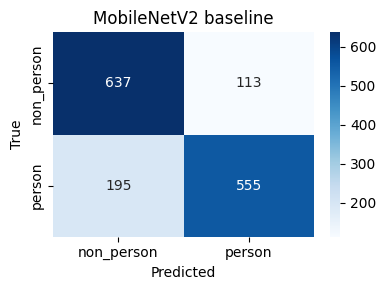

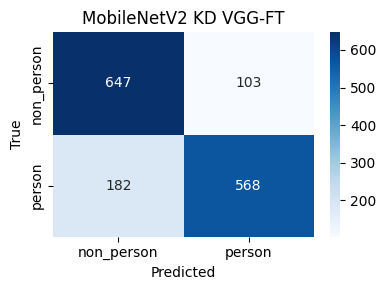

In [13]:
for name in key_models:
    if name not in results or results[name]['acc'] is None:
        continue
    r = results[name]
    plot_confusion(r['preds'], r['labels'], title=name)

## 10 · Save results to file

In [14]:
import json

# Save a clean summary (no preds/labels — just accuracy numbers)
summary = {name: round(r['acc']*100, 2)
           for name, r in results.items()
           if r['acc'] is not None}

out_path = Path('/content/drive/My Drive/stm32-thesis/outputs/final_test_results.json')
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(summary, indent=2))

print('Saved to:', out_path)
print(json.dumps(summary, indent=2))

Saved to: /content/drive/My Drive/stm32-thesis/outputs/final_test_results.json
{
  "MobileNetV2 baseline": 79.47,
  "MobileNetV3 baseline": 79.13,
  "VGG Pretrained (teacher)": 90.6,
  "ResNet Pretrained (teacher)": 89.73,
  "MobileNetV2 KD VGG-FT": 81.0,
  "MobileNetV3 KD VGG-scratch": 82.4,
  "MobileNetV2 pruned unstructured 10%": 80.4,
  "MobileNetV2 pruned unstructured 30%": 78.47
}
